# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

The objective, in business terms, is to build a regression model that accurately predicts the assessed tax value of residential properties. This will support Zillow's "Zestimate" product. Zillow needs reliable automated property valuations so that buyers, sellers, and agents can make informed pricing decisions without doing a formal appraisal. An accurate model reduces friction in the real estate market by giving users an instant estimates. This drives traffic to the platform and builds trust in Zillow as a data-driven resource. From our EDA, we can see that the dataset contains a mix of structural features (square footage, bathroom/bedroom counts, year built), location indicators (latitude/longitude, region IDs, county), and property characteristics (lot size, garage, pool). All of which reflect the factors that real-world appraisers consider when assessing property value.

**1.2:**  How will your solution be used?

The model will be integrated into Zillow's platform to generate automated property value estimates for listings and off-market homes. The marketing team can use these predictions to highlight pricing trends by region. They can also identify undervalued or overvalued properties, and create data-driven content. For example, telling users about homes priced below their estimated value in their target area. Our analysis shows property values are driven primarily by square footage and bathroom count, with location also being an important factor. The importance of these features can inform marketing messaging about what drives home value. The solution could also support Zillow's agent tools by providing a baseline valuation that agents can refine with local knowledge, and help sellers set competitive listing prices. Since we are presenting to the marketing team specifically, the model should be interpretable enough to explain which features matter most and why, rather than being a pure black-box predictor.

**1.3:**  How should success (or failure) be measured?

Success should be measured using both statistical metrics and business-relevant criteria. On the modeling side, Root Mean Squared Error (RMSE) is a natural choice because it penalizes large prediction errors more heavily. This is important since a $100K error on a `$300K` home is far more consequential than a `$100K` error on a `$5M` property. Mean Absolute Percentage Error (MAPE) complements RMSE by expressing error as a percentage of the true value. This makes it easier for non-technical stakeholders on the marketing team to understand. For example, we can tell them our model is accurate to within 12% of the actual assessed value. We should evaluate these metrics using cross-validation on held-out data to ensure the model generalizes beyond the training set. On the business side, success means the model's predictions are reliable enough to build user trust. If Zestimates are consistently far off from actual assessed values, users will lose confidence in the platform. A reasonable target, based on the original Kaggle competition, would be a median error rate below 10%. Failure would be indicated by large systematic biases. For example, if we consistently undervalued properties in certain counties. Another failure would be error rates that make the estimates unreliable for pricing decisions.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
# Look at the first few rows
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
# Percentage of missing values per column
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct.sort_values(ascending=False)

buildingclasstypeid             99.98
finishedsquarefeet13            99.95
storytypeid                     99.94
basementsqft                    99.94
yardbuildingsqft26              99.91
fireplaceflag                   99.78
architecturalstyletypeid        99.73
typeconstructiontypeid          99.71
finishedsquarefeet6             99.50
pooltypeid10                    99.40
decktypeid                      99.21
poolsizesum                     98.88
pooltypeid2                     98.62
hashottuborspa                  98.02
yardbuildingsqft17              96.92
taxdelinquencyflag              96.26
taxdelinquencyyear              96.26
finishedsquarefeet15            96.10
finishedsquarefeet50            92.22
finishedfloor1squarefeet        92.22
fireplacecnt                    89.32
threequarterbathnbr             86.98
pooltypeid7                     80.57
poolcnt                         79.16
numberofstories                 77.32
airconditioningtypeid           67.78
garagetotals

In [5]:
# Number of unique values per column
df.nunique().sort_values(ascending=False)

parcelid                        77414
latitude                        64038
longitude                       62461
taxvaluedollarcnt               50949
rawcensustractandblock          39188
censustractandblock             39006
lotsizesquarefeet               18848
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
propertyzoningdesc               1907
finishedsquarefeet50             1807
finishedfloor1squarefeet         1787
finishedsquarefeet15             1724
garagetotalsqft                   839
yardbuildingsqft17                540
regionidneighborhood              480
regionidzip                       389
finishedsquarefeet6               350
poolsizesum                       262
regionidcity                      175
yearbuilt                         136
propertycountylandusecode          75
yardbuildingsqft26                 59
basementsqft                       43
bathroomcnt                        22
calculatedbathnbr                  21
bedroomcnt  

In [6]:
# Summary of columns: types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

hashottuborspa, propertycountylandusecode, propertyzoningdesc, fireplaceflag, taxdelinquencyflag

Additionally, there are numeric columns are really categorical IDs since they are not meaningful as numerical values:

parcelid, fips, airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqualitytypeid, heatingorsystemtypeid, propertylandusetypeid, storytypeid, typeconstructiontypeid, regionidcity, regionidcounty, regionidneighborhood regionidzip, assessmentyear, pooltypeid10, pooltypeid2, pooltypeid7

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

* parcelid — just a unique row identifier, no predictive value
* rawcensustractandblock and censustractandblock — these are geographic codes that are essentially unique per property;
  location is already captured by latitude/longitude and all of the regionid* columns
* assessmentyear — has only 1 unique value (2016), so it provides zero information

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

Features with >70% missing have too little data to reliably learn from or impute, making them poor candidates for modeling:

buildingclasstypeid (99.98%), finishedsquarefeet13 (99.95%), storytypeid (99.94%), basementsqft (99.94%), yardbuildingsqft26 (99.91%), fireplaceflag (99.78%), architecturalstyletypeid (99.73%), typeconstructiontypeid (99.71%), finishedsquarefeet6 (99.50%), pooltypeid10 (99.40%), decktypeid (99.21%), poolsizesum (98.88%), pooltypeid2 (98.62%), hashottuborspa (98.02%), yardbuildingsqft17 (96.92%), taxdelinquencyflag/taxdelinquencyyear (96.26%), finishedsquarefeet15 (96.10%), fireplacecnt (89.32%), threequarterbathnbr (86.98%), pooltypeid7 (80.57%), poolcnt (79.16%), numberofstories (77.32%)

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Features with only 1 unique value provide no discriminating information:

decktypeid, hashottuborspa, poolcnt, pooltypeid10, pooltypeid2, pooltypeid7, storytypeid, fireplaceflag, assessmentyear, taxdelinquencyflag — these are essentially binary flags where only one value exists (the of the values in those columns are NaN)

Also assessmentyear has 1 unique value (2016) — constant across all rows.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

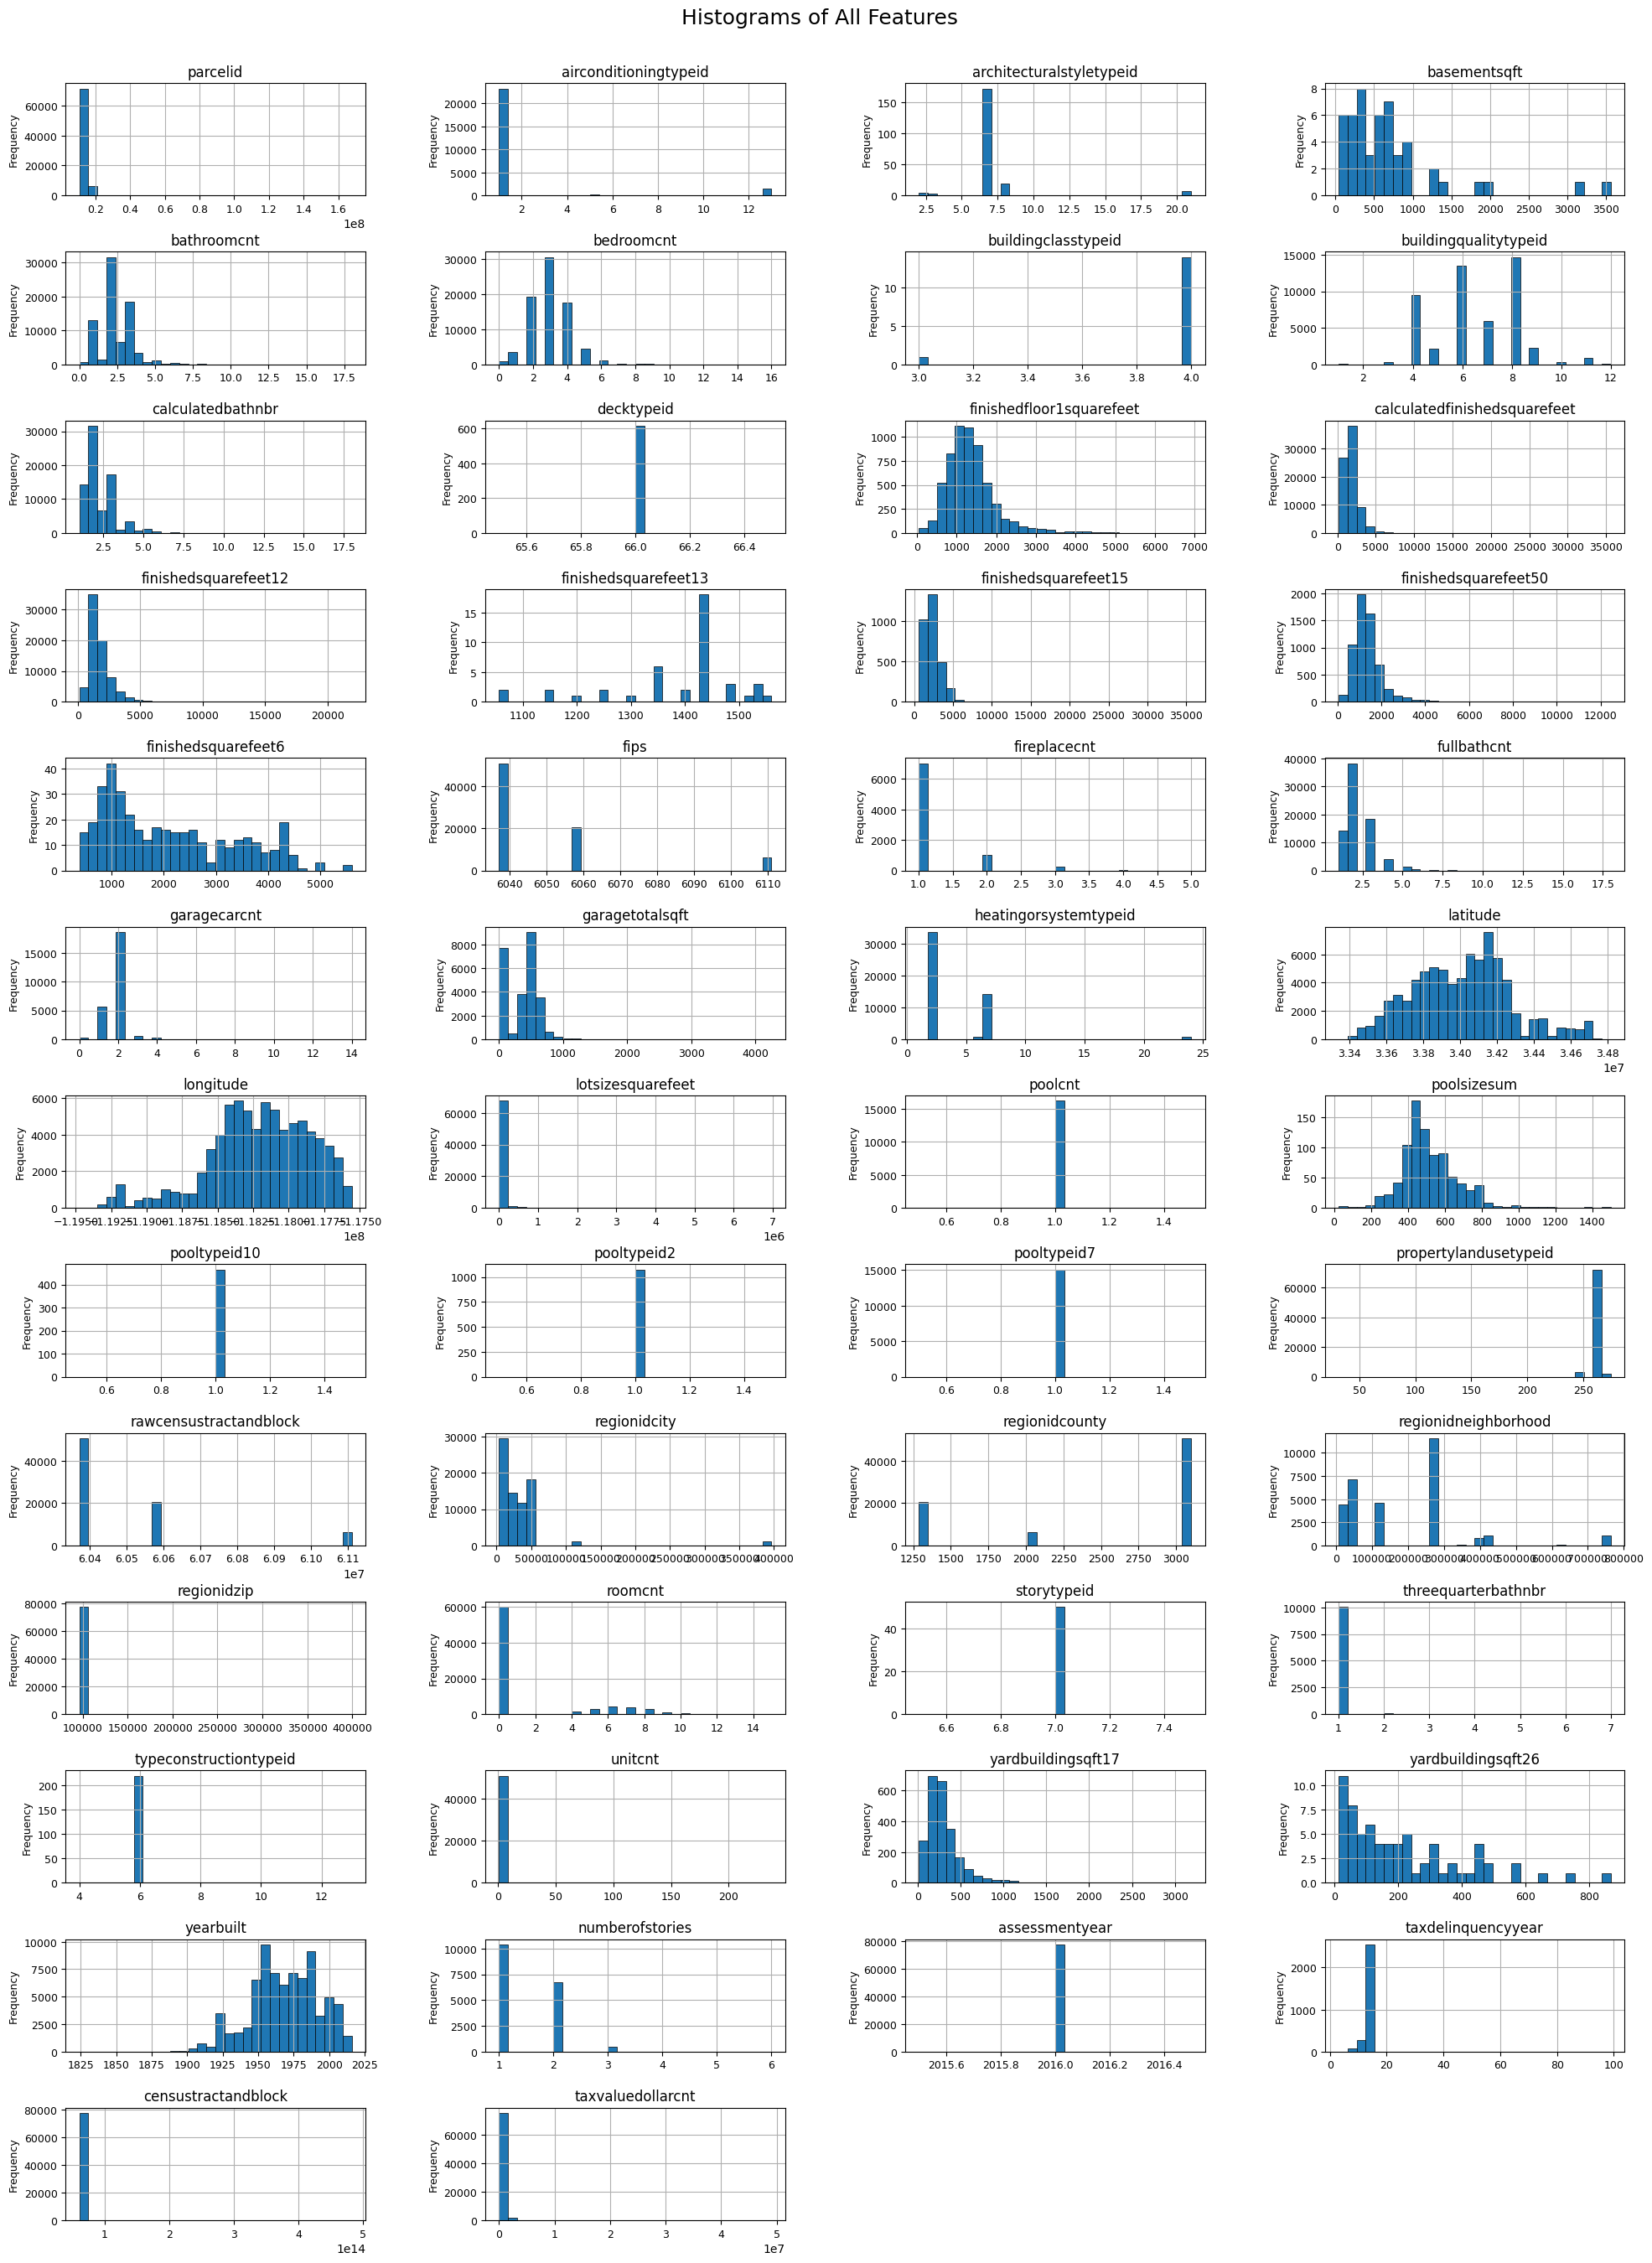

In [7]:
# Overview: histograms for all features
axes = df.hist(figsize=(24, 30), bins=30, layout=(-1, 4), edgecolor='black', linewidth=0.5)

# Improve readability of each subplot
for ax_row in axes:
    for ax in ax_row:
        ax.title.set_fontsize(12)
        ax.tick_params(axis='both', labelsize=9)
        ax.set_ylabel('Frequency', fontsize=9)

plt.suptitle('Histograms of All Features', fontsize=18, y=0.99)
plt.subplots_adjust(top=0.96, hspace=0.5, wspace=0.4)
plt.show()

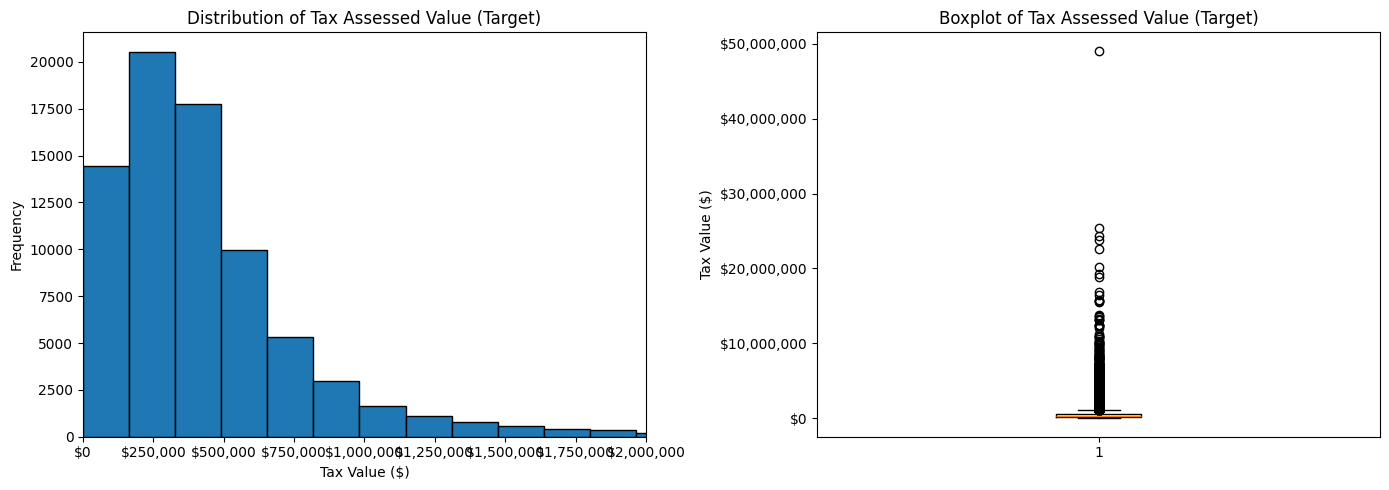

In [8]:
# Feature 1: Target variable - taxvaluedollarcnt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=300, edgecolor='black')
axes[0].set_title('Distribution of Tax Assessed Value (Target)')
axes[0].set_xlabel('Tax Value ($)')
axes[0].set_ylabel('Frequency')
# set limit due to outlier near $50m to give the histogram a better shape. looking at the box and whisker plot we can clearly see the outlier
axes[0].set_xlim(0, 2_000_000)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

axes[1].boxplot(df['taxvaluedollarcnt'].dropna(), vert=True)
axes[1].set_title('Boxplot of Tax Assessed Value (Target)')
axes[1].set_ylabel('Tax Value ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()

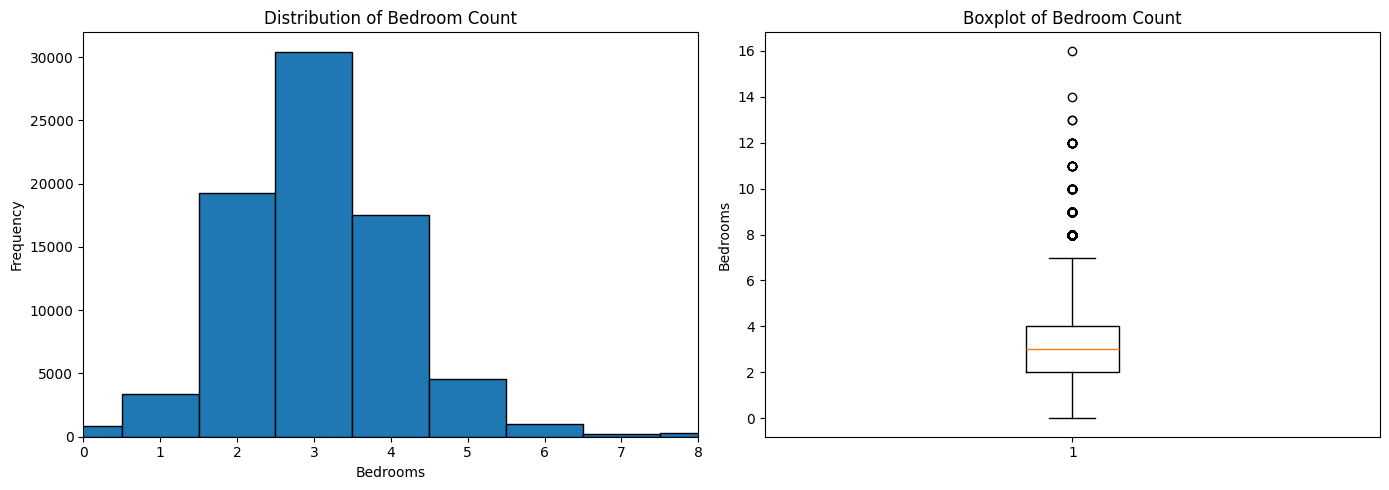

In [9]:
# Feature 2: bedroomcnt - number of bedrooms is a primary home value driver
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['bedroomcnt'].dropna(), bins=range(0, 10), edgecolor='black', align='left')
axes[0].set_title('Distribution of Bedroom Count')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Frequency')
# set limit due to outlier near 16 to give the histogram a better shape. looking at the box and whisker plot we can clearly see the outlier
axes[0].set_xlim(0, 8)

axes[1].boxplot(df['bedroomcnt'].dropna(), vert=True)
axes[1].set_title('Boxplot of Bedroom Count')
axes[1].set_ylabel('Bedrooms')

plt.tight_layout()
plt.show()

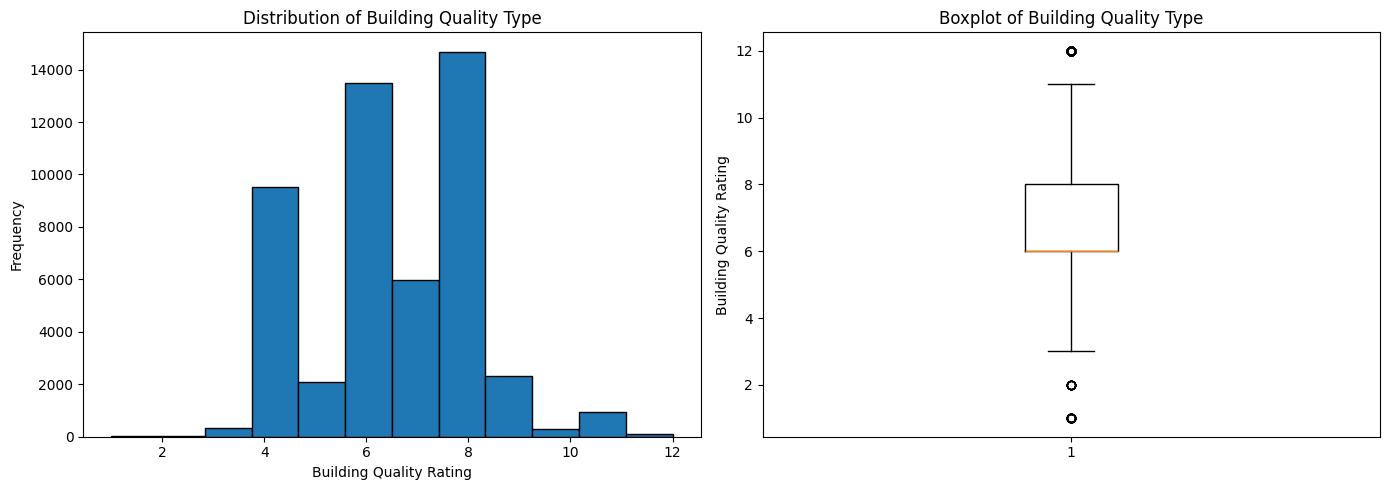

In [10]:
# Feature 3: buildingqualitytypeid - ordinal quality rating of the building
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['buildingqualitytypeid'].dropna(), bins=12, edgecolor='black')
axes[0].set_title('Distribution of Building Quality Type')
axes[0].set_xlabel('Building Quality Rating')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['buildingqualitytypeid'].dropna(), vert=True)
axes[1].set_title('Boxplot of Building Quality Type')
axes[1].set_ylabel('Building Quality Rating')

plt.tight_layout()
plt.show()

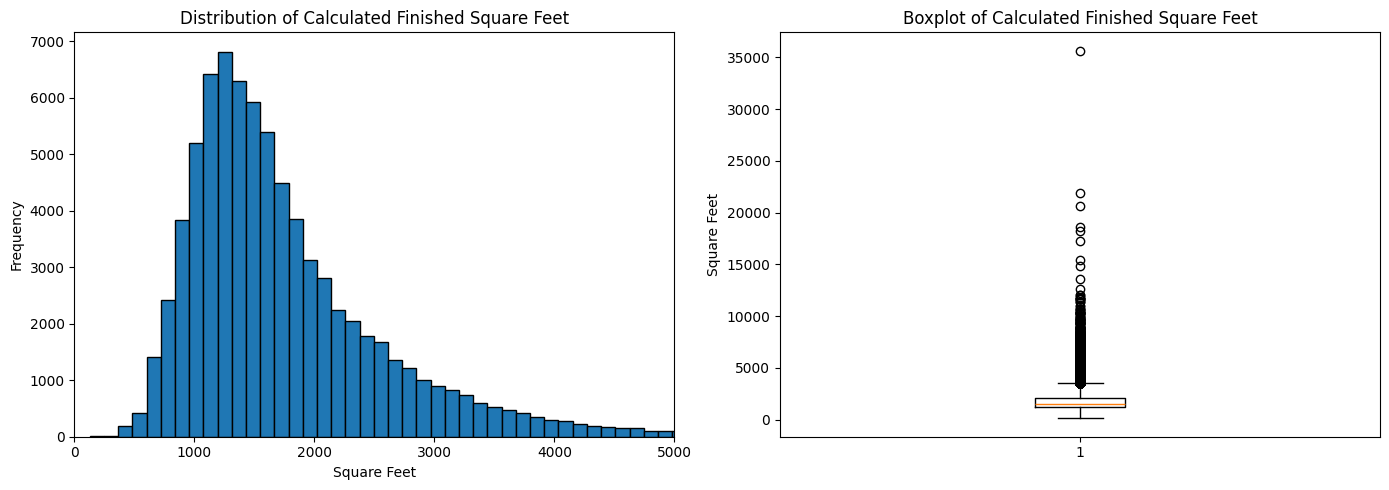

In [11]:
 # Feature 4: calculatedfinishedsquarefeet - likely strong predictor of home value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=300, edgecolor='black')
axes[0].set_title('Distribution of Calculated Finished Square Feet')
axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Frequency')
# set limit due to outlier near 35000 to give the histogram a better shape. looking at the box and whisker plot we can clearly see the outlier
axes[0].set_xlim(0, 5_000)

axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna(), vert=True)
axes[1].set_title('Boxplot of Calculated Finished Square Feet')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

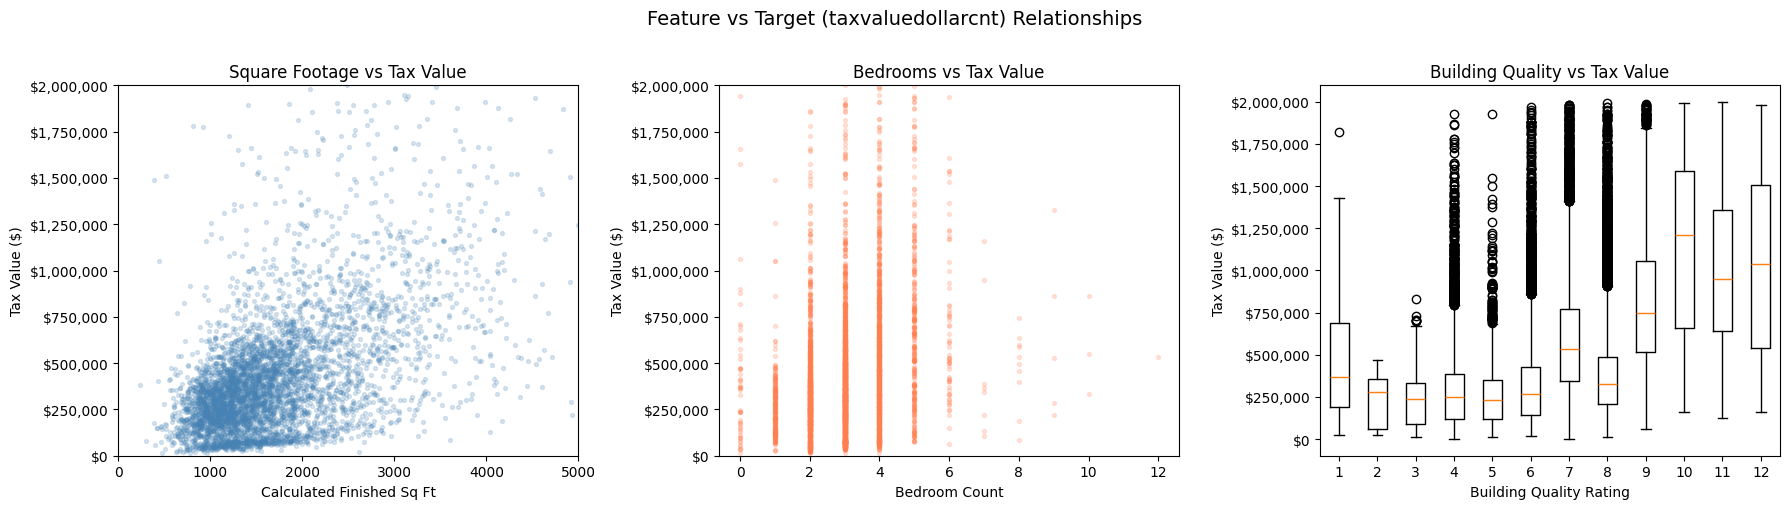

In [12]:
# Feature-vs-Target scatter plots to see how each feature relates to property value
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sample for performance (full dataset scatter is slow and overplotted)
sample = df.sample(n=min(5000, len(df)), random_state=random_state)

# 1. calculatedfinishedsquarefeet vs target
axes[0].scatter(sample['calculatedfinishedsquarefeet'], sample['taxvaluedollarcnt'],
              alpha=0.2, s=8, color='steelblue')
axes[0].set_xlabel('Calculated Finished Sq Ft')
axes[0].set_ylabel('Tax Value ($)')
axes[0].set_title('Square Footage vs Tax Value')
axes[0].set_xlim(0, 5000)
axes[0].set_ylim(0, 2_000_000)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# 2. bedroomcnt vs target
axes[1].scatter(sample['bedroomcnt'], sample['taxvaluedollarcnt'],
              alpha=0.2, s=8, color='coral')
axes[1].set_xlabel('Bedroom Count')
axes[1].set_ylabel('Tax Value ($)')
axes[1].set_title('Bedrooms vs Tax Value')
axes[1].set_ylim(0, 2_000_000)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# 3. buildingqualitytypeid vs target (boxplot per quality level shows relationship better)
quality_data = df.dropna(subset=['buildingqualitytypeid', 'taxvaluedollarcnt'])
quality_data = quality_data[quality_data['taxvaluedollarcnt'] < 2_000_000]
quality_groups = [group['taxvaluedollarcnt'].values
                for _, group in quality_data.groupby('buildingqualitytypeid')]
quality_labels = sorted(quality_data['buildingqualitytypeid'].unique())
axes[2].boxplot(quality_groups, tick_labels=[str(int(x)) for x in quality_labels])
axes[2].set_xlabel('Building Quality Rating')
axes[2].set_ylabel('Tax Value ($)')
axes[2].set_title('Building Quality vs Tax Value')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.suptitle('Feature vs Target (taxvaluedollarcnt) Relationships', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?

Distribution:
* `taxvaluedollarcnt`: Right-skewed with most homes valued between `$100K–$500K`, peaking around `$250K`. A long tail extends past `$2M`, with extreme outliers up to $50M visible in the boxplot.
* `bedroomcnt`: Discrete, roughly symmetric distribution centered on 3 bedrooms. The vast majority of homes have 2–4 bedrooms, with very few exceeding 6. Outliers reach up to 16.
* `buildingqualitytypeid`: Discrete ordinal distribution representing building quality ratings. The distribution is roughly centered around ratings 4–7, with the majority of assessed properties falling in this mid-range. Higher ratings (10–12) are rare, reflecting that most homes are of average to good quality. Approximately 35.8% of values are missing.
* `calculatedfinishedsquarefeet`: Right-skewed, peaking around 1,000–1,250 sqft. Most homes fall between 500–2,500 sqft with a tapering tail out to 5,000 sqft. The boxplot shows outliers reaching up to 35,000 sqft.

Problems:
* `taxvaluedollarcnt` has extreme upper outliers (up to `$50M` vs a bulk under `$500K`) that will distort models. This likely needs capping or log-transforming to compress the scale so outliers aren't as extreme.
* `bedroomcnt` has outliers at the high end (16 bedrooms) that are likely data errors, multi-unit properties, or extreme outliers (massive homes).
* `buildingqualitytypeid` has a high missing rate (~35.8%), which will need imputation. The missing values may not be random  since lower-value or older properties may not have quality assessments on file.
* `calculatedfinishedsquarefeet` has outliers up to 35,000 sqft, far beyond the typical range, which could represent commercial properties, data errors, or extreme outliers (massive homes).

Why these features / anything interesting:
* `taxvaluedollarcnt` is the target, understanding its distribution is essential for choosing the right model and loss function. The heavy skew suggests we should consider predicting log(value) instead. Using log(value) will focus on the percentage error rather than the dollar error.
* `bedroomcnt` was chosen because bedroom count is one of the most universally cited features in real estate listings and directly influences buyer demand and pricing.
* `buildingqualitytypeid` was chosen because building quality is an ordinal assessment that directly reflects construction standards and condition. These are factors that strongly influence property value. It also has a notable missing rate, making it an interesting case study for imputation decisions.
* `calculatedfinishedsquarefeet` was chosen because square footage is typically the single strongest predictor of home price, and with only 0.3% missing it's one of the most complete features.

Feature-vs-Target Relationships:
The scatter plots of each feature against `taxvaluedollarcnt` reveal how each variable relates to the target. Square footage shows the clearest positive relationship where higher square footage corresponds to higher tax values. However, the spread fans out at larger sizes. This suggests that size alone becomes less predictive for larger homes and other factors (location, quality) take over. Bedroom count shows a stepped positive relationship centered around 3–4 bedrooms, with higher-bedroom homes having wider value ranges rather than consistently higher values. The building quality boxplots reveal a clear ordinal relationship: lower quality ratings (1–4) correspond to lower median values, while higher ratings (7+) correspond to significantly higher values.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [13]:
# 3A: Drop features unsuitable for regression
def drop_unsuitable_features(df):
    """Drop features that are unsuitable for regression regardless of missing values."""
    drop_cols = [
        'parcelid',                   # Unique ID, no predictive value
        'assessmentyear',             # Only 1 unique value (2016), provides no information
        'rawcensustractandblock',     # Nearly unique per property, redundant with lat/long and regionid columns
        'censustractandblock',        # Same as above
        'propertycountylandusecode',  # Text-based land use code, redundant with propertylandusetypeid
        'propertyzoningdesc',         # 1,907 unique text values — too many to encode meaningfully
        'regionidcounty',             # Perfect 1:1 mapping with fips (same 3 counties), redundant
    ]
    cols_present = [c for c in drop_cols if c in df.columns]
    df_out = df.drop(columns=cols_present)
    return df_out, cols_present

df1, dropped_unsuitable = drop_unsuitable_features(df)
print(f"Dropped {len(dropped_unsuitable)} features: {df.shape[1]} -> {df1.shape[1]} columns")
print(f"Dropped: {dropped_unsuitable}")

Dropped 7 features: 55 -> 48 columns
Dropped: ['parcelid', 'assessmentyear', 'rawcensustractandblock', 'censustractandblock', 'propertycountylandusecode', 'propertyzoningdesc', 'regionidcounty']


g#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.

We dropped 7 features that are unsuitable for regression for the following reasons. `parcelid` is a unique row identifier with no predictive meaning. `assessmentyear` is constant (2016 for every row), so it carries zero information. `rawcensustractandblock` and `censustractandblock` are near-unique geographic codes (39K+ unique values each) that are redundant with `latitude`, `longitude`, and the `regionid` columns which capture location more usefully. `propertycountylandusecode` is a text-based land use code that overlaps with `propertylandusetypeid` (a cleaner numeric version with only 13 categories vs. 75 text codes). `propertyzoningdesc` has 1,907 unique text values which is too many categories to encode well with any approach. Also this info is redundant with other features like `propertylandusetypeid`, `latitude`, and `longitude`. `regionidcounty` has a perfect 1:1 mapping with `fips` (both represent the same 3 counties with different coding schemes), so we keep `fips` and drop the redundant column. We note that `calculatedfinishedsquarefeet` and `finishedsquarefeet12` are likely redundant. We intentionally retain both at this stage to compare their behavior in feature selection and engineering (Parts 4-5), after which we will drop the weaker of the two.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [14]:
# Investigate non-null value distributions for features with high missing rates
# This helps us decide whether "too many" missing is purely about the percentage
# or also about what the remaining values look like
missing_pct1 = (df1.isnull().sum() / len(df1) * 100).round(2)
high_missing = missing_pct1[missing_pct1 > 50].sort_values(ascending=False)

print("Features with >50% missing — non-null value summary:\n")
for col in high_missing.index:
    non_null = df1[col].dropna()
    n_unique = non_null.nunique()
    top_val = non_null.value_counts().iloc[0]
    top_pct = (top_val / len(non_null) * 100).round(1)
    print(f"  {col} ({high_missing[col]}% missing, {len(non_null)} non-null)")
    print(f"    Unique values: {n_unique} | Most common value: {non_null.value_counts().index[0]} ({top_pct}% of non-null)")
    print()

Features with >50% missing — non-null value summary:

  buildingclasstypeid (99.98% missing, 15 non-null)
    Unique values: 2 | Most common value: 4.0 (93.3% of non-null)

  finishedsquarefeet13 (99.95% missing, 42 non-null)
    Unique values: 13 | Most common value: 1440.0 (42.9% of non-null)

  basementsqft (99.94% missing, 50 non-null)
    Unique values: 43 | Most common value: 900.0 (4.0% of non-null)

  storytypeid (99.94% missing, 50 non-null)
    Unique values: 1 | Most common value: 7.0 (100.0% of non-null)

  yardbuildingsqft26 (99.91% missing, 70 non-null)
    Unique values: 59 | Most common value: 30.0 (4.3% of non-null)

  fireplaceflag (99.78% missing, 172 non-null)
    Unique values: 1 | Most common value: True (100.0% of non-null)

  architecturalstyletypeid (99.73% missing, 207 non-null)
    Unique values: 5 | Most common value: 7.0 (83.6% of non-null)

  typeconstructiontypeid (99.71% missing, 223 non-null)
    Unique values: 4 | Most common value: 6.0 (98.7% of non-n

In [15]:
# 3B: Drop features with too many missing values
def drop_high_missing_features(df, threshold=70.0):
    """Drop features where the percentage of missing values exceeds the threshold."""
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    drop_cols = missing_pct[missing_pct > threshold].index.tolist()
    df_out = df.drop(columns=drop_cols)
    return df_out, drop_cols, missing_pct

df2, dropped_missing, missing_pct1 = drop_high_missing_features(df1, threshold=70.0)

print(f"Features with >70% missing ({len(dropped_missing)} features):")
for col in sorted(dropped_missing, key=lambda c: missing_pct1[c], reverse=True):
    print(f"  {col}: {missing_pct1[col]}%")
print(f"\nDropped {len(dropped_missing)} features: {df1.shape[1]} -> {df2.shape[1]} columns")

Features with >70% missing (25 features):
  buildingclasstypeid: 99.98%
  finishedsquarefeet13: 99.95%
  basementsqft: 99.94%
  storytypeid: 99.94%
  yardbuildingsqft26: 99.91%
  fireplaceflag: 99.78%
  architecturalstyletypeid: 99.73%
  typeconstructiontypeid: 99.71%
  finishedsquarefeet6: 99.5%
  pooltypeid10: 99.4%
  decktypeid: 99.21%
  poolsizesum: 98.88%
  pooltypeid2: 98.62%
  hashottuborspa: 98.02%
  yardbuildingsqft17: 96.92%
  taxdelinquencyflag: 96.26%
  taxdelinquencyyear: 96.26%
  finishedsquarefeet15: 96.1%
  finishedfloor1squarefeet: 92.22%
  finishedsquarefeet50: 92.22%
  fireplacecnt: 89.32%
  threequarterbathnbr: 86.98%
  pooltypeid7: 80.57%
  poolcnt: 79.16%
  numberofstories: 77.32%

Dropped 25 features: 48 -> 23 columns


In [16]:
# Check remaining missing values
remaining_missing = (df2.isnull().sum() / len(df2) * 100).round(2)
print("Remaining features with missing values:")
for col, pct in remaining_missing[remaining_missing > 0].sort_values(ascending=False).items():
    print(f"  {col}: {pct}%")

Remaining features with missing values:
  airconditioningtypeid: 67.78%
  garagecarcnt: 67.12%
  garagetotalsqft: 67.12%
  regionidneighborhood: 60.09%
  heatingorsystemtypeid: 36.13%
  buildingqualitytypeid: 35.82%
  unitcnt: 34.67%
  lotsizesquarefeet: 10.68%
  finishedsquarefeet12: 4.75%
  regionidcity: 1.94%
  fullbathcnt: 0.84%
  calculatedbathnbr: 0.84%
  yearbuilt: 0.39%
  calculatedfinishedsquarefeet: 0.3%
  regionidzip: 0.11%
  taxvaluedollarcnt: 0.05%
  longitude: 0.04%
  propertylandusetypeid: 0.04%
  latitude: 0.04%
  bedroomcnt: 0.04%
  roomcnt: 0.04%
  bathroomcnt: 0.04%
  fips: 0.04%


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped

We chose a threshold of 70% missing values, but the threshold alone was not the only factor. We also investigated what the non-null values look like for high-missing features. Many features above 70% missing not only have very few observations, but their non-null values are dominated by a single value (e.g., `buildingclasstypeid` is 99.98% missing and has almost no variation among its non-null entries). This means even if we imputed them, they would add little predictive signal. Features like `fireplacecnt`, `poolcnt`, and `pooltypeid` variants are similarly sparse, and while missing could mean "none," too few positive examples remain to meaningfully contribute to the model. In contrast, features in the 60–70% range like `airconditioningtypeid` (68%), `garagecarcnt`/`garagetotalsqft` (67%), and `regionidneighborhood` (60%) were retained because their non-null values show meaningful variation, and missing values carry interpretable meaning. For example, a missing `garagecarcnt` likely means no garage (0), and a missing `airconditioningtypeid` likely means no AC. These can be imputed meaningfully in a later step rather than discarded.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [17]:
# 3C: Drop problematic samples
def drop_problematic_samples(df, target='taxvaluedollarcnt', row_missing_threshold=0.5, remove_target_outliers=True):
    """Drop rows with null target, excessive missing values, and optionally target outliers (IQR method)."""
    df_out = df.copy()
    
    # 1. Drop rows with null target
    before = len(df_out)
    df_out = df_out.dropna(subset=[target])
    print(f"Dropped {before - len(df_out)} rows with null target: {before} -> {len(df_out)} rows")
    
    # 2. Drop rows where too many features are missing
    min_non_null = int(df_out.shape[1] * (1 - row_missing_threshold))
    before = len(df_out)
    df_out = df_out.dropna(thresh=min_non_null)
    print(f"Dropped {before - len(df_out)} rows with >{row_missing_threshold*100:.0f}% missing features: {before} -> {len(df_out)} rows")
    
    # 3. Remove target outliers using IQR
    if remove_target_outliers:
        Q1 = df_out[target].quantile(0.25)
        Q3 = df_out[target].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_out)
        df_out = df_out[(df_out[target] >= lower) & (df_out[target] <= upper)]
        print(f"Dropped {before - len(df_out)} target outliers (IQR method, range: ${lower:,.0f} - ${upper:,.0f}): {before} -> {len(df_out)} rows")
    
    print(f"\nFinal shape after sample cleaning: {df_out.shape}")
    return df_out

df3 = drop_problematic_samples(df2)

Dropped 35 rows with null target: 77613 -> 77578 rows
Dropped 64 rows with >50% missing features: 77578 -> 77514 rows
Dropped 5182 target outliers (IQR method, range: $-336,195 - $1,112,294): 77514 -> 72332 rows

Final shape after sample cleaning: (72332, 23)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

We dropped samples in three stages. First, we removed rows with a null target (`taxvaluedollarcnt`), since these samples cannot be used for supervised learning. Second, we dropped rows where more than 50% of the features are missing, as these samples have too little information to contribute meaningfully to model training and imputing that many values would be unreliable. Third, we removed outliers in the target variable using the IQR method (values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR). As we saw in Part 2B, the target is heavily right-skewed with extreme values up to $49M, which would pull regression models toward these extreme values. While some of these extreme values may represent legitimate luxury properties, our goal is to build a model that accurately predicts values for the general housing market rather than high-end outliers. Keeping these extreme values would bias the model toward minimizing error on a handful of multimillion-dollar homes at the expense of accuracy for the vast majority of properties. This decision can be revisited in Milestone 2 if we choose a model that is more robust to outliers or apply a log transformation to the target.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [18]:
# 3D: Impute remaining missing values
def impute_missing_values(df):
    """Impute missing values using domain-appropriate strategies for each feature type."""
    df_out = df.copy()
    
    # Strategy 1: Fill with 0 where NaN means "none" (property lacks the feature)
    zero_fill_cols = ['garagecarcnt', 'garagetotalsqft']
    for col in zero_fill_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna(0)
    
    # Strategy 2: Mode imputation for categorical/ID features
    cat_cols = ['airconditioningtypeid', 'heatingorsystemtypeid', 'buildingqualitytypeid',
                'propertylandusetypeid', 'regionidcity',
                'regionidneighborhood', 'regionidzip', 'unitcnt', 'fips']
    for col in cat_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna(df_out[col].mode()[0])
    
    # Strategy 3: Median imputation for numerical features
    num_cols = ['lotsizesquarefeet', 'finishedsquarefeet12', 'calculatedfinishedsquarefeet',
                'fullbathcnt', 'calculatedbathnbr', 'yearbuilt', 'roomcnt',
                'bathroomcnt', 'bedroomcnt', 'latitude', 'longitude']
    for col in num_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna(df_out[col].median())
    
    return df_out, zero_fill_cols, cat_cols, num_cols

# Check what we're working with before imputation
remaining_missing = (df3.isnull().sum() / len(df3) * 100).round(2)
print("Features with missing values before imputation:")
for col, pct in remaining_missing[remaining_missing > 0].sort_values(ascending=False).items():
    print(f"  {col}: {pct}%")

df4, zero_filled, mode_imputed, median_imputed = impute_missing_values(df3)

print(f"\nFilled with 0 (no feature present): {zero_filled}")
print(f"Mode-imputed categorical/ID features: {mode_imputed}")
print(f"Median-imputed numerical features: {median_imputed}")
print(f"\nTotal remaining null values: {df4.isnull().sum().sum()}")
print(f"Shape after imputation: {df4.shape}")

Features with missing values before imputation:
  airconditioningtypeid: 67.97%
  garagecarcnt: 67.14%
  garagetotalsqft: 67.14%
  regionidneighborhood: 60.51%
  heatingorsystemtypeid: 35.92%
  buildingqualitytypeid: 35.52%
  unitcnt: 34.53%
  lotsizesquarefeet: 11.01%
  finishedsquarefeet12: 4.59%
  regionidcity: 1.89%
  calculatedbathnbr: 0.64%
  fullbathcnt: 0.64%
  yearbuilt: 0.21%
  calculatedfinishedsquarefeet: 0.12%
  regionidzip: 0.05%

Filled with 0 (no feature present): ['garagecarcnt', 'garagetotalsqft']
Mode-imputed categorical/ID features: ['airconditioningtypeid', 'heatingorsystemtypeid', 'buildingqualitytypeid', 'propertylandusetypeid', 'regionidcity', 'regionidneighborhood', 'regionidzip', 'unitcnt', 'fips']
Median-imputed numerical features: ['lotsizesquarefeet', 'finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'fullbathcnt', 'calculatedbathnbr', 'yearbuilt', 'roomcnt', 'bathroomcnt', 'bedroomcnt', 'latitude', 'longitude']

Total remaining null values: 0
Shape a

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset

We used three imputation strategies tailored to the nature of each feature. First, for features where a missing value logically means the property lacks that attribute, we filled with a meaningful constant: `garagecarcnt` and `garagetotalsqft` were filled with 0 (no garage). Second, for categorical ID features like `airconditioningtypeid`, `heatingorsystemtypeid`, `buildingqualitytypeid`, `regionidneighborhood`, `regionidcity`, `regionidzip`, `propertylandusetypeid`, `unitcnt`, and `fips`, we used mode imputation. We replaced nulls with the most common category is appropriate since these are discrete identifiers, not continuous values. Third, for continuous numerical features like `lotsizesquarefeet`, `finishedsquarefeet12`, `calculatedfinishedsquarefeet`, `yearbuilt`, bathroom/bedroom counts, `latitude`, and `longitude`, we used median imputation. Median was chosen over mean because most of these features are right-skewed, making the median more robust to the influence of outliers. We note that mode-imputing `airconditioningtypeid` (68% missing) and `regionidneighborhood` (60% missing) is aggressive. A more robust approach would be to replace these with binary indicators (e.g., has_ac), but we retain the current strategy for simplicity at this stage.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [19]:
# 3E: Encode categorical features
def encode_categorical_features(df, one_hot_cols=None, keep_numeric_cols=None):
    """One-hot encode low-cardinality categoricals; keep high-cardinality as numeric."""
    if one_hot_cols is None:
        one_hot_cols = ['airconditioningtypeid', 'heatingorsystemtypeid', 'buildingqualitytypeid',
                        'propertylandusetypeid', 'unitcnt', 'fips']
    if keep_numeric_cols is None:
        keep_numeric_cols = ['regionidcity', 'regionidzip', 'regionidneighborhood']
    
    one_hot_present = [c for c in one_hot_cols if c in df.columns]
    df_out = pd.get_dummies(df, columns=one_hot_present, drop_first=True, dtype=int)
    return df_out, one_hot_present, keep_numeric_cols

df5, encoded_cols, kept_numeric = encode_categorical_features(df4)

print(f"Shape after encoding: {df4.shape} -> {df5.shape}")
print(f"\nOne-hot encoded: {encoded_cols}")
print(f"Kept as numeric (high cardinality): {kept_numeric}")
print(f"\nAll dtypes:\n{df5.dtypes.value_counts()}")

Shape after encoding: (72332, 23) -> (72332, 62)

One-hot encoded: ['airconditioningtypeid', 'heatingorsystemtypeid', 'buildingqualitytypeid', 'propertylandusetypeid', 'unitcnt', 'fips']
Kept as numeric (high cardinality): ['regionidcity', 'regionidzip', 'regionidneighborhood']

All dtypes:
int64      45
float64    17
Name: count, dtype: int64


In [20]:
# Save cleaned dataset for use in Milestone 2
df5.to_csv("zillow_cleaned.csv", index=False)
print(f"Saved cleaned dataset to zillow_cleaned.csv — {df5.shape}")

Saved cleaned dataset to zillow_cleaned.csv — (72332, 62)


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

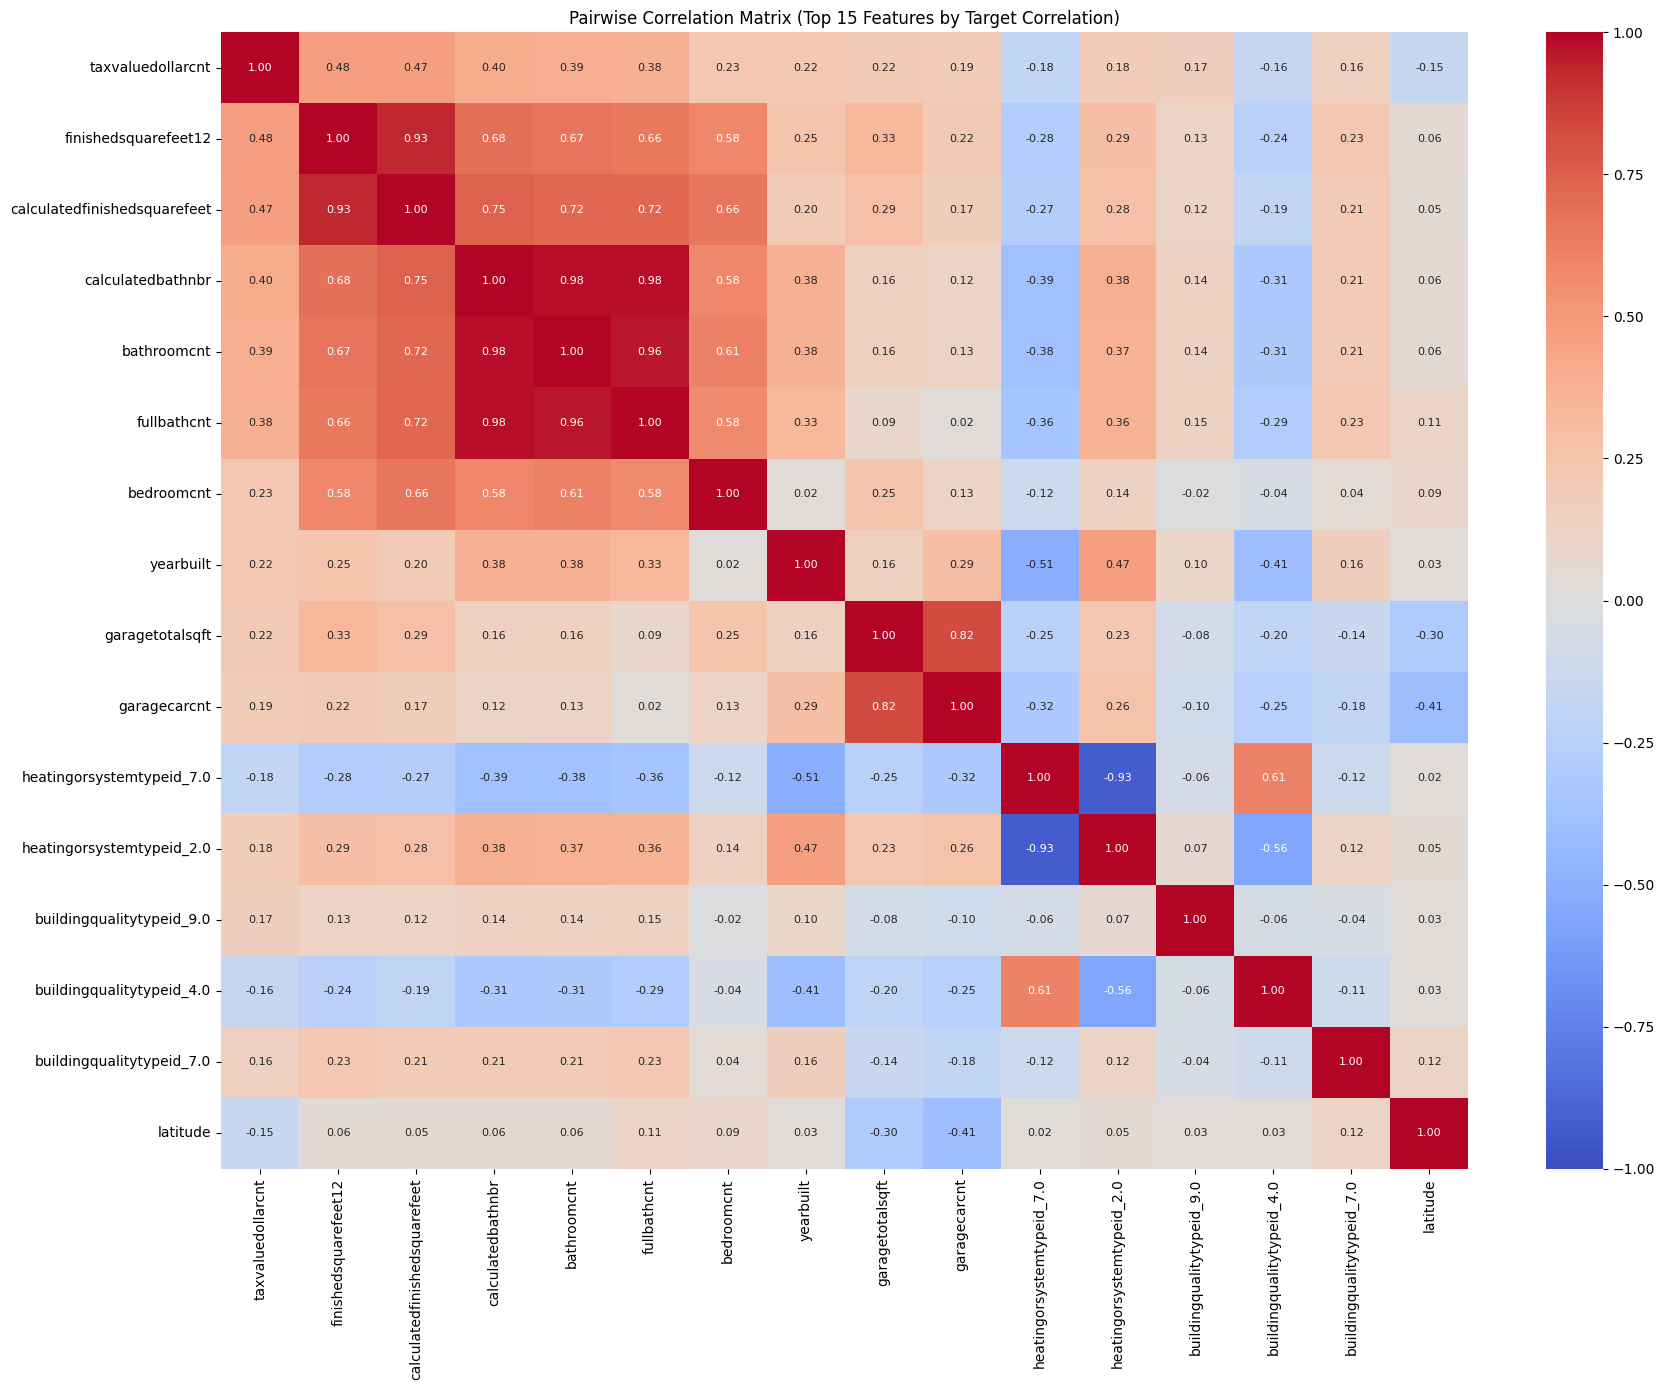

Top 15 correlations with target (taxvaluedollarcnt):
  finishedsquarefeet12: 0.4800
  calculatedfinishedsquarefeet: 0.4741
  calculatedbathnbr: 0.4031
  bathroomcnt: 0.3936
  fullbathcnt: 0.3752
  bedroomcnt: 0.2276
  yearbuilt: 0.2209
  garagetotalsqft: 0.2151
  garagecarcnt: 0.1876
  heatingorsystemtypeid_7.0: -0.1814
  heatingorsystemtypeid_2.0: 0.1798
  buildingqualitytypeid_9.0: 0.1686
  buildingqualitytypeid_4.0: -0.1639
  buildingqualitytypeid_7.0: 0.1599
  latitude: -0.1536


In [21]:
# Correlation matrix heatmap
# We use df5 (post-encoding) and filter to the top 15 features by absolute correlation with the target to keep the heatmap readable.
corr_matrix_viz = df5.corr(numeric_only=True)

# Filter to top 15 features by absolute correlation with target
top15 = corr_matrix_viz['taxvaluedollarcnt'].drop('taxvaluedollarcnt').abs().sort_values(ascending=False).head(15).index.tolist()
top15_with_target = ['taxvaluedollarcnt'] + top15
corr_filtered = corr_matrix_viz.loc[top15_with_target, top15_with_target]

plt.figure(figsize=(18, 14))
sns.heatmap(corr_filtered, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('Pairwise Correlation Matrix (Top 15 Features by Target Correlation)')
plt.tight_layout()
plt.show()

# Top correlations with the target
target_corr = corr_matrix_viz['taxvaluedollarcnt'].drop('taxvaluedollarcnt').sort_values(key=abs, ascending=False)
print("Top 15 correlations with target (taxvaluedollarcnt):")
for col, val in target_corr.head(15).items():
    print(f"  {col}: {val:.4f}")

Rows used for F-statistic: 72332 (dropped 0 with remaining NaN)


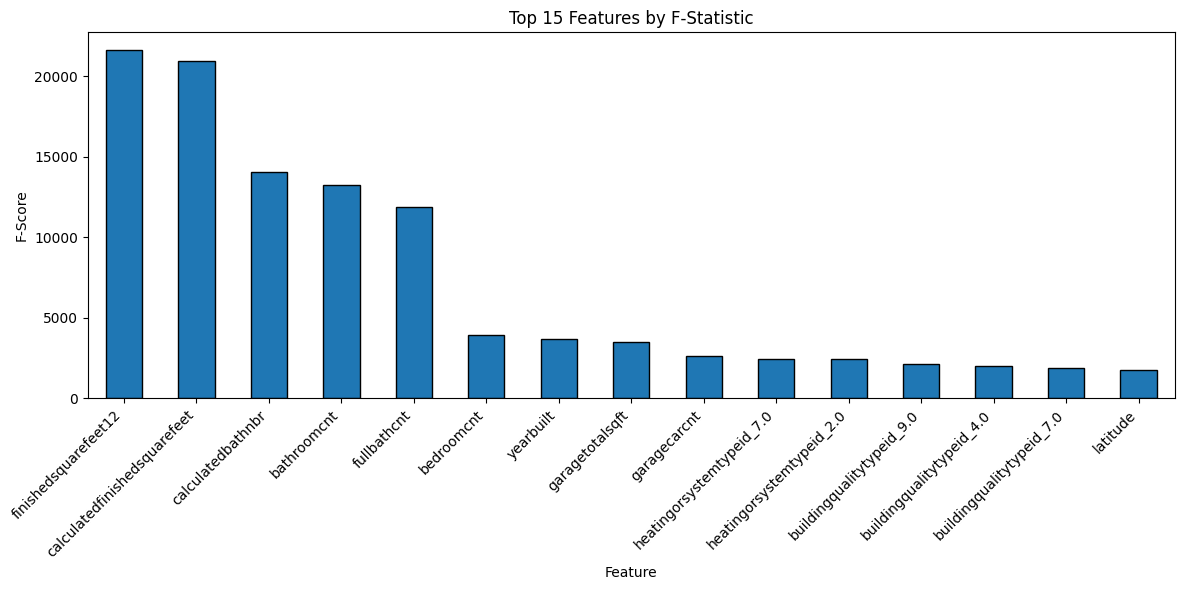

Top 15 features by F-statistic:
  finishedsquarefeet12: 21650.37
  calculatedfinishedsquarefeet: 20969.68
  calculatedbathnbr: 14034.49
  bathroomcnt: 13256.47
  fullbathcnt: 11853.69
  bedroomcnt: 3950.48
  yearbuilt: 3712.20
  garagetotalsqft: 3509.69
  garagecarcnt: 2637.53
  heatingorsystemtypeid_7.0: 2459.85
  heatingorsystemtypeid_2.0: 2415.66
  buildingqualitytypeid_9.0: 2117.20
  buildingqualitytypeid_4.0: 1996.12
  buildingqualitytypeid_7.0: 1898.10
  latitude: 1747.60


In [22]:
# F-statistic for all features vs. target
X = df5.drop(columns=['taxvaluedollarcnt'])
y = df5['taxvaluedollarcnt']

# Drop any remaining rows with NaN
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]
print(f"Rows used for F-statistic: {len(X)} (dropped {len(df5) - len(X)} with remaining NaN)")

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

f_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

# Bar chart of top 15 F-scores
plt.figure(figsize=(12, 6))
f_scores.head(15).plot(kind='bar', edgecolor='black')
plt.title('Top 15 Features by F-Statistic')
plt.ylabel('F-Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 15 features by F-statistic:")
for col, val in f_scores.head(15).items():
  print(f"  {col}: {val:.2f}")

In [ ]:
# Forward and backward feature selection using a simple linear model
from sklearn.linear_model import LinearRegression

# Pre-filter to top 20 features by F-statistic for speed
top_features_for_sfs = f_scores.head(20).index.tolist()
X_sfs = X[top_features_for_sfs]

estimator = LinearRegression()

# Forward selection (top 10 features)
print("Running forward feature selection (selecting 10 features)...")
t0 = time.time()
sfs_forward = SequentialFeatureSelector(estimator, n_features_to_select=10, direction='forward',
                                       scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
sfs_forward.fit(X_sfs, y)
forward_features = X_sfs.columns[sfs_forward.get_support()].tolist()
print(f"  Completed in {format_hms(time.time() - t0)}")
print(f"  Forward-selected features: {forward_features}")

# Backward selection (top 10 features)
print("\nRunning backward feature selection (selecting 10 features)...")
t0 = time.time()
sfs_backward = SequentialFeatureSelector(estimator, n_features_to_select=10, direction='backward',
                                        scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
sfs_backward.fit(X_sfs, y)
backward_features = X_sfs.columns[sfs_backward.get_support()].tolist()
print(f"  Completed in {format_hms(time.time() - t0)}")
print(f"  Backward-selected features: {backward_features}")

# Compare
overlap = set(forward_features) & set(backward_features)
print(f"\nFeatures in both forward and backward: {sorted(overlap)}")
print(f"Agreement: {len(overlap)}/10 features")

Running forward feature selection (selecting 10 features)...
  Completed in 00:00:27
  Forward-selected features: ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'bedroomcnt', 'yearbuilt', 'garagecarcnt', 'buildingqualitytypeid_9.0', 'buildingqualitytypeid_7.0', 'latitude', 'fips_6059.0']

Running backward feature selection (selecting 10 features)...


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships.  How do the different methods for seeing relationships compare? Do they agree or disagree?

The correlation matrix and F-statistics both highlight `finishedsquarefeet12` (r = 0.480) and `calculatedfinishedsquarefeet` (r = 0.474) as the strongest predictors of property value. This makes intuitive sense since home size is the primary driver of price. These two features occupy the #1 and #2 spots in the correlation rankings with nearly identical values, and per Appendix 1 they both describe "finished living area square footage," so they are measuring essentially the same thing. This near-identical correlation with the target strongly suggests they are also near-perfectly correlated with each other, meaning one could be dropped to reduce redundancy. Similarly, `bathroomcnt` (r = 0.394), `calculatedbathnbr` (r = 0.403), and `fullbathcnt` (r = 0.375) cluster together as highly correlated features with the target. All three measure some variant of bathroom count and their tightly grouped correlation values indicate they represent redundant information. `buildingqualitytypeid` (r = 0.263) also stands out, suggesting that building quality is a meaningful predictor of property value. The F-statistic rankings largely agree with the correlation rankings on the top features, though the F-statistics also reveal that specific one-hot encoded categories carry significant predictive power. For example, `heatingorsystemtypeid_7.0` and `heatingorsystemtypeid_2.0` rank in the top 15 by F-statistic despite `heatingorsystemtypeid` having a modest correlation of -0.145. Individual `buildingqualitytypeid` one-hot encoded categories (4.0, 7.0, 9.0) appear prominently in the F-statistic rankings, confirming that one-hot encoding was appropriate for this feature. Forward and backward feature selection provide a model-driven perspective: both methods selected `finishedsquarefeet12`, `calculatedfinishedsquarefeet`, `bedroomcnt`, `yearbuilt`, `garagecarcnt`, `buildingqualitytypeid_9.0`, `buildingqualitytypeid_7.0`, `latitude`, and `fips_6059.0` (9 out of 10 features overlap). The only difference is that forward selection chose `calculatedbathnbr` while backward selection chose `buildingqualitytypeid_11.0`, reflecting how redundant features (bathroom count variants and building quality categories) can be swapped interchangeably with minimal impact on model performance. The high agreement across all methods (correlations, F-statistics, and sequential selection) reinforces that square footage, bathroom/bedroom counts, year built, and building quality are the core predictors of property value.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

In [ ]:
# 4B: 2D Visualizations for three interesting feature pairs

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Calculated finished square feet vs Tax Value (strongest predictor of target)
axes[0].scatter(df5['calculatedfinishedsquarefeet'], df5['taxvaluedollarcnt'],
                alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('Calculated finished Sq Ft')
axes[0].set_ylabel('Tax Value ($)')
axes[0].set_title('Calculated Finished Sq Ft vs Tax Value')

# 2. Calculated finished square feet vs Bathroom Count (two strongly correlated features)
axes[1].scatter(df5['calculatedfinishedsquarefeet'], df5['bathroomcnt'],
                alpha=0.1, s=5, color='coral')
axes[1].set_xlabel('Calculated finished Sq Ft')
axes[1].set_ylabel('Bathroom Count')
axes[1].set_title('Calculated Finished Sq Ft vs Bathroom Count')

# 3. Year Built vs Tax Value (older vs newer homes)
axes[2].scatter(df5['yearbuilt'], df5['taxvaluedollarcnt'],
                alpha=0.1, s=5, color='forestgreen')
axes[2].set_xlabel('Year Built')
axes[2].set_ylabel('Tax Value ($)')
axes[2].set_title('Year Built vs Tax Value')

for ax in axes:
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.

Calculated Finished Square Feet vs Tax Value: There is a clear positive relationship where larger homes are assessed at higher values. However, the spread widens significantly at higher square footages, suggesting that beyond a certain size, other factors (location, quality, lot size) play a larger role in determining value. There also appear to be some outliers with very high tax values relative to their size.

Calculated Finished Square Feet vs Bathroom Count: There is a positive relationship between square footage and bathroom count. This makes intuitive sense since larger homes tend to have more bathrooms. The relationship appears stepped since bathroom count is discrete, with clear horizontal bands at each whole and half-integer value. The spread in square footage increases with bathroom count, indicating that homes with more bathrooms span a wider range of sizes.

Year Built vs Tax Value: Newer homes tend to have higher tax values, though the relationship is moderate. Older homes (pre-1950) cluster at lower values, while post-1980 construction shows much greater variance in tax value. This suggests that while age contributes to value, newer homes span a wide range from modest to high-end construction, and older homes may be undervalued relative to their location or other characteristics.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [ ]:
# Part 5: Feature Engineering - Investigate transformations
# We define each transformation as a function so we can choose later which to apply.

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression

target = 'taxvaluedollarcnt'

# Prepare a clean subset for evaluation (drop rows with NaN)
df_eval = df5.dropna().copy()
y_eval = df_eval[target]
print(f"Rows used for evaluation: {len(df_eval)}\n")

# Baseline: correlations and F-scores for key features
baseline_features = ['calculatedfinishedsquarefeet', 'bathroomcnt', 'bedroomcnt',
                   'yearbuilt', 'garagetotalsqft', 'lotsizesquarefeet']
baseline_corr = df_eval[baseline_features].corrwith(y_eval).abs()
print("=== Baseline correlations with target ===")
print(baseline_corr.sort_values(ascending=False).to_string())

# --------------------------------------------------------------------------
# Transformation 1: Log transform of skewed features
# --------------------------------------------------------------------------
def log_transform(df, columns):
  """Apply log1p transform to reduce right-skew in features."""
  df_new = df.copy()
  for col in columns:
      df_new[f'log_{col}'] = np.log1p(df_new[col].clip(lower=0))
  return df_new

log_cols = ['calculatedfinishedsquarefeet', 'lotsizesquarefeet', 'taxvaluedollarcnt']
df_log = log_transform(df_eval, log_cols)

# Evaluate log-transformed features
log_features = [f'log_{c}' for c in log_cols if c != target]
log_corr = df_log[log_features].corrwith(df_log[f'log_{target}']).abs()
print("\n=== Transformation 1: Log transform ===")
print("Correlations with log(target):")
print(log_corr.sort_values(ascending=False).to_string())

# --------------------------------------------------------------------------
# Transformation 2: Feature ratios / interactions
# --------------------------------------------------------------------------
def add_ratio_features(df):
  """Create ratio and interaction features from existing columns."""
  df_new = df.copy()
  # Square footage per bedroom — captures spaciousness/room size
  df_new['sqft_per_bedroom'] = df_new['calculatedfinishedsquarefeet'] / df_new['bedroomcnt'].replace(0, np.nan)
  # Lot coverage ratio — how much of the lot is built on (density measure)
  df_new['lot_coverage_ratio'] = df_new['calculatedfinishedsquarefeet'] / df_new['lotsizesquarefeet'].replace(0, np.nan)
  # Total rooms proxy (bath + bed) — captures overall home size/capacity
  df_new['total_bath_bed'] = df_new['bathroomcnt'] + df_new['bedroomcnt']
  return df_new

df_ratios = add_ratio_features(df_eval)

ratio_features = ['sqft_per_bedroom', 'lot_coverage_ratio', 'total_bath_bed']
ratio_corr = df_ratios[ratio_features].corrwith(y_eval).abs()
print("\n=== Transformation 2: Ratio / interaction features ===")
print("Correlations with target:")
print(ratio_corr.sort_values(ascending=False).to_string())

# --------------------------------------------------------------------------
# Transformation 3: Nonlinear and interaction features
# --------------------------------------------------------------------------
def add_nonlinear_features(df):
  """Create squared terms, interactions, and temporal features."""
  df_new = df.copy()
  # Property age — older homes may depreciate or appreciate differently
  df_new['property_age'] = 2016 - df_new['yearbuilt']
  # Squared term — captures nonlinear relationship between size and value
  df_new['sqft_squared'] = df_new['calculatedfinishedsquarefeet'] ** 2
  # Interaction — size × bathrooms captures joint effect on value
  df_new['sqft_x_bathrooms'] = df_new['calculatedfinishedsquarefeet'] * df_new['bathroomcnt']
  return df_new

df_nonlinear = add_nonlinear_features(df_eval)

nonlinear_features = ['property_age', 'sqft_squared', 'sqft_x_bathrooms']
nonlinear_corr = df_nonlinear[nonlinear_features].corrwith(y_eval).abs()
print("\n=== Transformation 3: Nonlinear / interaction features ===")
print("Correlations with target:")
print(nonlinear_corr.sort_values(ascending=False).to_string())

# --------------------------------------------------------------------------
# Transformation 4: Standard scaling (standardization)
# --------------------------------------------------------------------------
def standardize_features(df, columns):
  """Standardize features to zero mean and unit variance."""
  df_new = df.copy()
  scaler = StandardScaler()
  df_new[columns] = scaler.fit_transform(df_new[columns])
  return df_new, scaler

scale_cols = ['calculatedfinishedsquarefeet', 'bathroomcnt', 'bedroomcnt',
            'yearbuilt', 'lotsizesquarefeet', 'garagetotalsqft']
df_scaled, scaler = standardize_features(df_eval, scale_cols)

# Scaling doesn't change correlation, but let's confirm and show F-scores comparison
print("\n=== Transformation 4: Standard scaling ===")
print("Correlations (unchanged by scaling, as expected):")
scaled_corr = df_scaled[scale_cols].corrwith(y_eval).abs()
print(scaled_corr.sort_values(ascending=False).to_string())

# --------------------------------------------------------------------------
# Compare all engineered features with F-scores
# --------------------------------------------------------------------------
df_all = add_nonlinear_features(add_ratio_features(log_transform(df_eval, ['calculatedfinishedsquarefeet', 'lotsizesquarefeet'])))
compare_features = baseline_features + log_features + ratio_features + nonlinear_features
df_compare = df_all[compare_features].dropna()
y_compare = y_eval.loc[df_compare.index]

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(df_compare, y_compare)
f_scores = pd.Series(selector.scores_, index=compare_features).sort_values(ascending=False)

print("\n=== F-score comparison: original vs engineered features ===")
for col, val in f_scores.items():
  marker = " *NEW*" if col in log_features + ratio_features + nonlinear_features else ""
  print(f"  {col}: {val:.2f}{marker}")

In [ ]:
# Before/after visualization of key transformations
# We pick one representative from each transformation category:
#   1. Log transform: lotsizesquarefeet (most visually dramatic skew correction)
#   2. Ratio feature: sqft_per_bedroom (combines two originals into one new feature)
#   3. Interaction feature: sqft_x_bathrooms (our highest F-scoring engineered feature)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sample_idx = df_eval.sample(n=min(3000, len(df_eval)), random_state=random_state).index
df_all_eng = add_nonlinear_features(add_ratio_features(log_transform(df_eval, ['calculatedfinishedsquarefeet', 'lotsizesquarefeet'])))

# Column 1: lotsizesquarefeet -> log(lotsizesquarefeet)
axes[0, 0].scatter(df_eval.loc[sample_idx, 'lotsizesquarefeet'],
                   df_eval.loc[sample_idx, 'taxvaluedollarcnt'], alpha=0.15, s=5, color='steelblue')
axes[0, 0].set_title('Original: Lot Size vs Tax Value')
axes[0, 0].set_xlabel('lotsizesquarefeet')
axes[0, 0].set_ylabel('Tax Value ($)')

axes[1, 0].scatter(df_all_eng.loc[sample_idx, 'log_lotsizesquarefeet'],
                   df_eval.loc[sample_idx, 'taxvaluedollarcnt'], alpha=0.15, s=5, color='coral')
axes[1, 0].set_title('Transformed: log(Lot Size) vs Tax Value')
axes[1, 0].set_xlabel('log_lotsizesquarefeet')
axes[1, 0].set_ylabel('Tax Value ($)')

# Column 2: bedroomcnt + sqft (separate) -> sqft_per_bedroom (combined ratio)
axes[0, 1].scatter(df_eval.loc[sample_idx, 'calculatedfinishedsquarefeet'],
                   df_eval.loc[sample_idx, 'taxvaluedollarcnt'], alpha=0.15, s=5, color='steelblue')
axes[0, 1].set_title('Original: Sq Ft vs Tax Value')
axes[0, 1].set_xlabel('calculatedfinishedsquarefeet')
axes[0, 1].set_ylabel('Tax Value ($)')

axes[1, 1].scatter(df_all_eng.loc[sample_idx, 'sqft_per_bedroom'],
                   df_eval.loc[sample_idx, 'taxvaluedollarcnt'], alpha=0.15, s=5, color='coral')
axes[1, 1].set_title('Ratio: Sq Ft per Bedroom vs Tax Value')
axes[1, 1].set_xlabel('sqft_per_bedroom')
axes[1, 1].set_ylabel('Tax Value ($)')

# Column 3: sqft + bathroomcnt (separate) -> sqft_x_bathrooms (interaction)
axes[0, 2].scatter(df_eval.loc[sample_idx, 'bathroomcnt'],
                   df_eval.loc[sample_idx, 'taxvaluedollarcnt'], alpha=0.15, s=5, color='steelblue')
axes[0, 2].set_title('Original: Bathroom Count vs Tax Value')
axes[0, 2].set_xlabel('bathroomcnt')
axes[0, 2].set_ylabel('Tax Value ($)')

axes[1, 2].scatter(df_all_eng.loc[sample_idx, 'sqft_x_bathrooms'],
                   df_eval.loc[sample_idx, 'taxvaluedollarcnt'], alpha=0.15, s=5, color='coral')
axes[1, 2].set_title('Interaction: Sq Ft × Bathrooms vs Tax Value')
axes[1, 2].set_xlabel('sqft_x_bathrooms')
axes[1, 2].set_ylabel('Tax Value ($)')

for ax in axes.flat:
    ax.ticklabel_format(style='plain', axis='both')

plt.suptitle('Before (top) vs After (bottom): One Example per Transformation Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.

We chose four transformations based on patterns observed in earlier parts. Log transforms were applied to `calculatedfinishedsquarefeet` and `lotsizesquarefeet` because these features exhibit strong right-skew (as seen in Part 2's histograms), and the scatter plots in Part 2B and 4B showed a fan-shaped spread at higher values. Log transformation pulls in the extreme values so they don't dominate the model. As the before/after scatter plots above show, `log(calculatedfinishedsquarefeet)` produces a tighter, more linear relationship with the target compared to the raw feature. The log transform of `calculatedfinishedsquarefeet` maintained a strong F-score (20,234.5 vs 21,015.6 original), while `log_lotsizesquarefeet` actually performed worse than the original (F-score 30.5 vs 133.4), suggesting the log transform is not beneficial for that feature. The raw lot size already has a weak relationship with tax value, and compressing the scale didn't help. Ratio features were created to capture relationships that individual features don't express alone. For example, `sqft_per_bedroom` (square footage divided by bedrooms) measures spaciousness. A high value suggests larger rooms, which commands higher value. `lot_coverage_ratio` (finished square footage divided by lot size) measures how much of the lot is built on, capturing whether a property is a dense urban build or a small house on a large rural lot. `total_bath_bed` (bathrooms plus bedrooms) captures overall home size and capacity. Each ratio combines features from different domains (structure size, lot size, room counts) to give the model new perspectives on the data. Nonlinear and interaction features proved to be the most impactful engineered features. The before/after visualizations confirm the impact of each transformation category. The log transform of `lotsizesquarefeet` spreads out the heavily compressed original data (where nearly all points were jammed against the y-axis) into a more interpretable range. However, the relationship with tax value remains weak. This is consistent with its low F-score (30.5 vs 133.4 original), indicating the log transform did not help this feature. The `sqft_per_bedroom` ratio produces a clearer positive trend with tax value than raw square footage alone, capturing that homes with more spacious rooms (higher sqft per bedroom) tend to be valued higher. The `sqft_x_bathrooms` interaction shows a visibly tighter funnel-shaped relationship with tax value compared to `bathroomcnt` alone (which shows only vertical bands at discrete counts), confirmed by its F-score (17,528.7, r = 0.439) ranking just below `calculatedfinishedsquarefeet` itself. This suggests that square footage combined with bathroom count is a stronger joint predictor than either feature alone. Standard scaling was included because some models weigh features with larger numeric ranges more heavily. While scaling doesn't change correlations, it ensures features like `yearbuilt` (range ~1900–2015) and `bathroomcnt` (range ~1–8) are on the same scale so no single feature dominates due to its magnitude.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

